# DigitClassifier Ziffernerkennung: Training und Export

Dieses Notebook zeigt, wie ein einfaches neuronales Netz auf einem Nummern Datensatz trainiert und als Modell für ein Web-Frontend exportiert wird.

In [16]:
!pip install tensorflow

## 1. Daten laden

Die mnist-digit-recognizer-Daten werden von Kaggle geladen und als CSV eingelesen.

In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("animatronbot/mnist-digit-recognizer")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-digit-recognizer' dataset.
Path to dataset files: /kaggle/input/mnist-digit-recognizer


In [33]:
import numpy as np
from sklearn.model_selection import train_test_split
import os

def load_data():
    data_dir = "/root/.cache/kagglehub/datasets/animatronbot/mnist-digit-recognizer/versions/1"
    data_file = os.path.join(data_dir, "train.csv") # Assuming the data file is named train.csv
    data = np.loadtxt(data_file, delimiter=",", skiprows=1)  # skiprows=1 überspringt die Header-Zeile

    label = data[:, 0]
    data = data[:, 1:]

    print(data, label)

    return data, label

X, y = load_data()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"Geladen: {len(X_train)} X_train")
print(f"Geladen: {len(y_train)} y_train")
print(f"Geladen: {len(X_test)} X_train")
print(f"Geladen: {len(y_test)} y_train")

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] [1. 0. 1. ... 7. 6. 9.]
Geladen: 33600 X_train
Geladen: 33600 y_train
Geladen: 8400 X_train
Geladen: 8400 y_train


## 2. Datenvisualisierung

Einige zufällige Trainingsbilder werden angezeigt, um die Daten zu überprüfen.

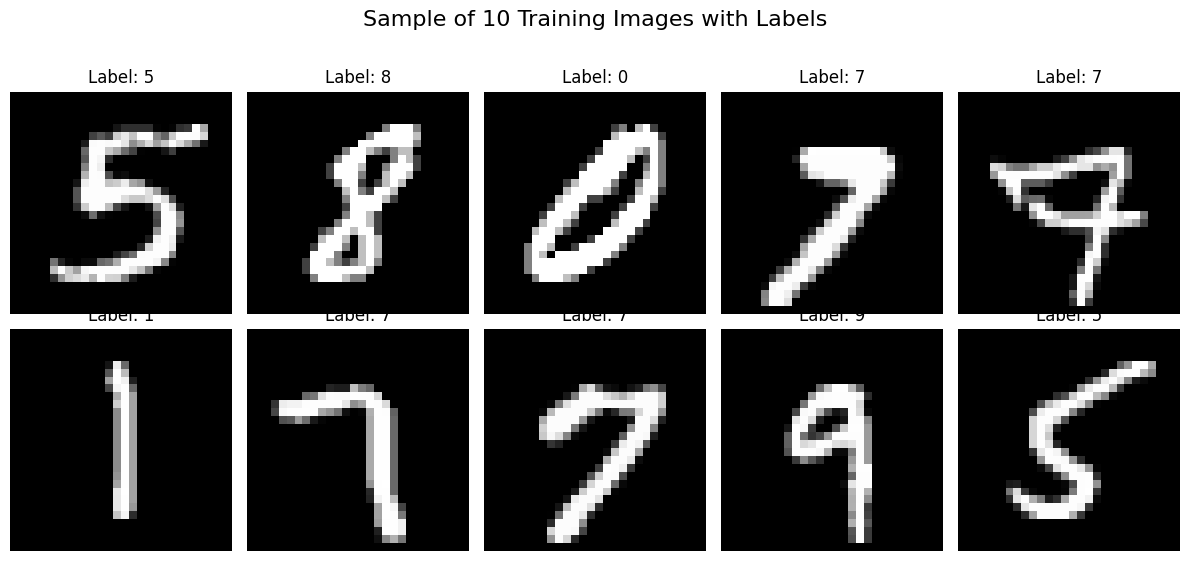

In [34]:
import matplotlib.pyplot as plt
import numpy as np

num_images_to_display = 10

random_indices = np.random.choice(len(X_train), num_images_to_display, replace=False)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)

    image = X_train[idx].reshape(28, 28)

    plt.imshow(image, cmap='gray')

    plt.title(f"Label: {int(y_train[idx])}")

    plt.axis('off')

plt.suptitle(f'Sample of {num_images_to_display} Training Images with Labels', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3. Modellaufbau

Ein einfaches neuronales Netz (MLP) mit mehreren Dense-Layern wird definiert.

In [35]:
from keras.models import Sequential
from keras.layers import Dense

In [36]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,706 (209.79 KB)

 Trainable params: 53,706 (209.79 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Training und Auswertung

Die Daten werden normalisiert und das Modell wird trainiert. Anschließend erfolgt die Auswertung auf den Testdaten.

In [37]:
from keras.utils import to_categorical

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

history = model.fit(
    X_train.reshape(-1, 784),
    y_train,
    epochs = 20,
    batch_size = 100,
)

Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8433 - loss: 0.5320
Epoch 2/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9400 - loss: 0.2012
Epoch 3/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1502
Epoch 4/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9627 - loss: 0.1234
Epoch 5/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9712 - loss: 0.0996
Epoch 6/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0860
Epoch 7/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9778 - loss: 0.0734
Epoch 8/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9804 - loss: 0.0651
Epoch 9/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.0533
Epoch 10/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9853 - loss: 0.0499
Epoch 11/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9860 - loss: 0.0458
Epoch 12/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [38]:
score = model.evaluate(X_test.reshape(-1, 784), y_test)
print(score)

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9683 - loss: 0.1448
[0.14477846026420593, 0.9683333039283752]


## 5. Export des Modells

Das trainierte Modell wird als `model.h5` gespeichert und kann im FastAPI-Backend verwendet werden.

In [ ]:
import keras
model.save("model.h5")